In [1]:
import pandas as pd

data = {
        "name":['abc','xyz','sss'],
        "age":[20,22,44]
}
data2 = {
        "name":['abc','xyz','sss'],
        "age":[20,22,44]
}

df = pd.DataFrame(data)
f = pd.DataFrame(data2)
print(f)
print(df)

  name  age
0  abc   20
1  xyz   22
2  sss   44
  name  age
0  abc   20
1  xyz   22
2  sss   44


In [2]:
df = pd.read_csv(r"C:\Users\Sephanya\Downloads\auto-mpg.csv")
df

,Unnamed: 0,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,0,307.0,8,130.0,3504,12.0,70,1,18.0
1,1,350.0,8,165.0,3693,11.5,70,1,15.0
2,2,318.0,8,150.0,3436,11.0,70,1,18.0
3,3,304.0,8,150.0,3433,12.0,70,1,16.0
4,4,302.0,8,140.0,3449,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...,...
393,393,140.0,4,86.0,2790,15.6,82,1,27.0
394,394,97.0,4,52.0,2130,24.6,82,2,44.0
395,395,135.0,4,84.0,2295,11.6,82,1,32.0
396,396,120.0,4,79.0,2625,18.6,82,1,28.0


In [3]:
df = pd.DataFrame( {
        "name":['abc','xyz','sss'],
        "age":[20,22,44]
})

df

,name,age
0,abc,20
1,xyz,22
2,sss,44


In [4]:
f = pd.DataFrame( {
        "name":['abc','xyz','sss'],
        "age":[30,22,44] 
})

f

,name,age
0,abc,30
1,xyz,22
2,sss,44


In [5]:
m = pd.merge(df,f, on = 'age',how = 'inner')
m

,name_x,age,name_y
0,xyz,22,xyz
1,sss,44,sss


In [6]:
m = pd.merge(df,f, on = 'age',how = 'left')
m

,name_x,age,name_y
0,abc,20,NaN
1,xyz,22,xyz
2,sss,44,sss


In [7]:
m = pd.merge(df,f, on = 'age')
m

,name_x,age,name_y
0,xyz,22,xyz
1,sss,44,sss


In [8]:
m = pd.merge(df,f, on = 'age',how = 'outer',indicator = True)
m

,name_x,age,name_y,_merge
0,abc,20,NaN,left_only
1,xyz,22,xyz,both
2,NaN,30,abc,right_only
3,sss,44,sss,both


In [9]:
m = pd.merge(df,f, left_index = True , right_index = True)
m

,name_x,age_x,name_y,age_y
0,abc,20,abc,30
1,xyz,22,xyz,22
2,sss,44,sss,44


In [10]:
import pandas as pd

df = pd.DataFrame({
    "user_id": [101, 102, 103],
    "name": ['abc', 'xyz', 'sss']
}, index=[11, 22, 33])

f = pd.DataFrame({
    "user_id": [101, 102, 104],
    "name": ['abc', 'xyz', 'sss']
}, index=[100, 200, 300])

print(f)
print(df)

     user_id name
100      101  abc
200      102  xyz
300      104  sss
    user_id name
11      101  abc
22      102  xyz
33      103  sss


In [11]:
import numpy as np
data = { 
        'Age':[25,np.nan,30,22,np.nan],
        'Score':[85,90,np.nan,75,80],
         'City':['New york','Paris','London', np.nan,'Paris']
}
dataf = pd.DataFrame(data)

In [12]:
print(dataf.isnull())

     Age  Score   City
0  False  False  False
1   True  False  False
2  False   True  False
3  False  False   True
4   True  False  False


In [13]:
print(dataf.notnull())                                                                                                                         

     Age  Score   City
0   True   True   True
1  False   True   True
2   True  False   True
3   True   True  False
4  False   True   True


In [14]:
df_clean_rows = dataf.dropna()
df_clean_cols = dataf.dropna(axis = 1)
df_clean_subset = dataf.dropna(subset=['Age'])

print(df_clean_rows)
print(df_clean_cols)
print(df_clean_subset)

    Age  Score      City
0  25.0   85.0  New york
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]
    Age  Score      City
0  25.0   85.0  New york
2  30.0    NaN    London
3  22.0   75.0       NaN


In [15]:
# Fill missing values properly
dataf['Age'].fillna(dataf['Age'].mean(), inplace=True)
dataf['City'].fillna(dataf['City'].mode()[0], inplace=True)

print(dataf)

         Age  Score      City
0  25.000000   85.0  New york
1  25.666667   90.0     Paris
2  30.000000    NaN    London
3  22.000000   75.0     Paris
4  25.666667   80.0     Paris


C:\Users\Sephanya\AppData\Local\Temp\ipykernel_17076\1049180034.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataf['Age'].fillna(dataf['Age'].mean(), inplace=True)
C:\Users\Sephanya\AppData\Local\Temp\ipykernel_17076\1049180034.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [16]:
from sklearn.impute import SimpleImputer, KNNImputer

# Strategy choices: 'mean', 'median', 'most_frequent', 'constant'
mean_imputer = SimpleImputer(strategy='mean')
dataf[['Age', 'Score']] = mean_imputer.fit_transform(dataf[['Age', 'Score']])

# K-Nearest Neighbors imputation based on similar samples
knn_imputer = KNNImputer(n_neighbors=2)
dataf_knn = knn_imputer.fit_transform(dataf[['Age', 'Score']])

dataf[['Age','Score']]

,Age,Score
0,25.000000,85.0
1,25.666667,90.0
2,30.000000,82.5
3,22.000000,75.0
4,25.666667,80.0


In [17]:
from sklearn.impute import SimpleImputer, KNNImputer

# Strategy choices: 'mean', 'median', 'most_frequent', 'constant'
median_imputer = SimpleImputer(strategy='median')
dataf[['Age', 'Score']] = median_imputer.fit_transform(dataf[['Age', 'Score']])

# K-Nearest Neighbors imputation based on similar samples
knn_imputer = KNNImputer(n_neighbors=2)
dataf_knn = knn_imputer.fit_transform(dataf[['Age', 'Score']])

dataf[['Age','Score']]

,Age,Score
0,25.000000,85.0
1,25.666667,90.0
2,30.000000,82.5
3,22.000000,75.0
4,25.666667,80.0


In [18]:
# 1. Create a sample DataFrame with duplicate rows
data = {
    'Name': ['Alice', 'Bob', 'Alice', 'Alice', 'Charlie'],
    'Age': [25, 30, 25, 26, 35],
    'City': ['New York', 'Paris', 'New York', 'London', 'Berlin']
}
dfr = pd.DataFrame(data)
print("Original DataFrame:")
print(dfr)
print("\n" + "="*40 + "\n")


# 2. Remove exact duplicate rows (keeps the first occurrence)
dfr_no_duplicates = dfr.drop_duplicates()
print("1. After removing exact duplicates (keeps first):")
print(dfr_no_duplicates)
print("\n" + "="*40 + "\n")

# 3. Remove duplicates based on a specific column
dfr_unique_names = dfr.drop_duplicates(subset=['Name'])
print("2. After removing duplicates based on 'Name' column only:")
print(dfr_unique_names)
print("\n" + "="*40 + "\n")



Original DataFrame:
      Name  Age      City
0    Alice   25  New York
1      Bob   30     Paris
2    Alice   25  New York
3    Alice   26    London
4  Charlie   35    Berlin


1. After removing exact duplicates (keeps first):
      Name  Age      City
0    Alice   25  New York
1      Bob   30     Paris
3    Alice   26    London
4  Charlie   35    Berlin


2. After removing duplicates based on 'Name' column only:
      Name  Age      City
0    Alice   25  New York
1      Bob   30     Paris
4  Charlie   35    Berlin




In [19]:
# 4. Remove duplicates and keep the LAST occurrence
df_keep_last = dfr.drop_duplicates(subset=['Name'], keep='last')
print("3. Keeping the LAST occurrence of duplicate names:")
print(df_keep_last)
print("\n" + "="*40 + "\n")

3. Keeping the LAST occurrence of duplicate names:
      Name  Age    City
1      Bob   30   Paris
3    Alice   26  London
4  Charlie   35  Berlin




In [20]:
dfr_drop_all = dfr.drop_duplicates(subset=['Name'],keep=False)
print("3. Keeping the LAST occurrence of duplicate names:")
print(dfr_drop_all)
print("\n" + "="*40 + "\n")

3. Keeping the LAST occurrence of duplicate names:
      Name  Age    City
1      Bob   30   Paris
4  Charlie   35  Berlin




In [21]:
dfr.drop_duplicates(inplace=True,ignore_index=True)
print("6.Original dataframe modified in place with a reset index:")
print(dfr)


6.Original dataframe modified in place with a reset index:
      Name  Age      City
0    Alice   25  New York
1      Bob   30     Paris
2    Alice   26    London
3  Charlie   35    Berlin


In [22]:
df2 = pd.read_csv(r"C:\Users\Sephanya\Downloads\house-prices-advanced-regression-techniques\train.csv")
df2

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [23]:
df2.describe

<bound method NDFrame.describe of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour 

In [24]:
df2.shape

(1460, 81)

In [25]:
pd.set_option('display,max_columns',None)

OptionError: No such keys(s): 'display,max_columns'

In [28]:
df2.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [29]:
df2.isnull()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1456,False,False,False,False,False,False,True,False,False,False,...,False,True,False,True,False,False,False,False,False,False
1457,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1458,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False


<Axes: >

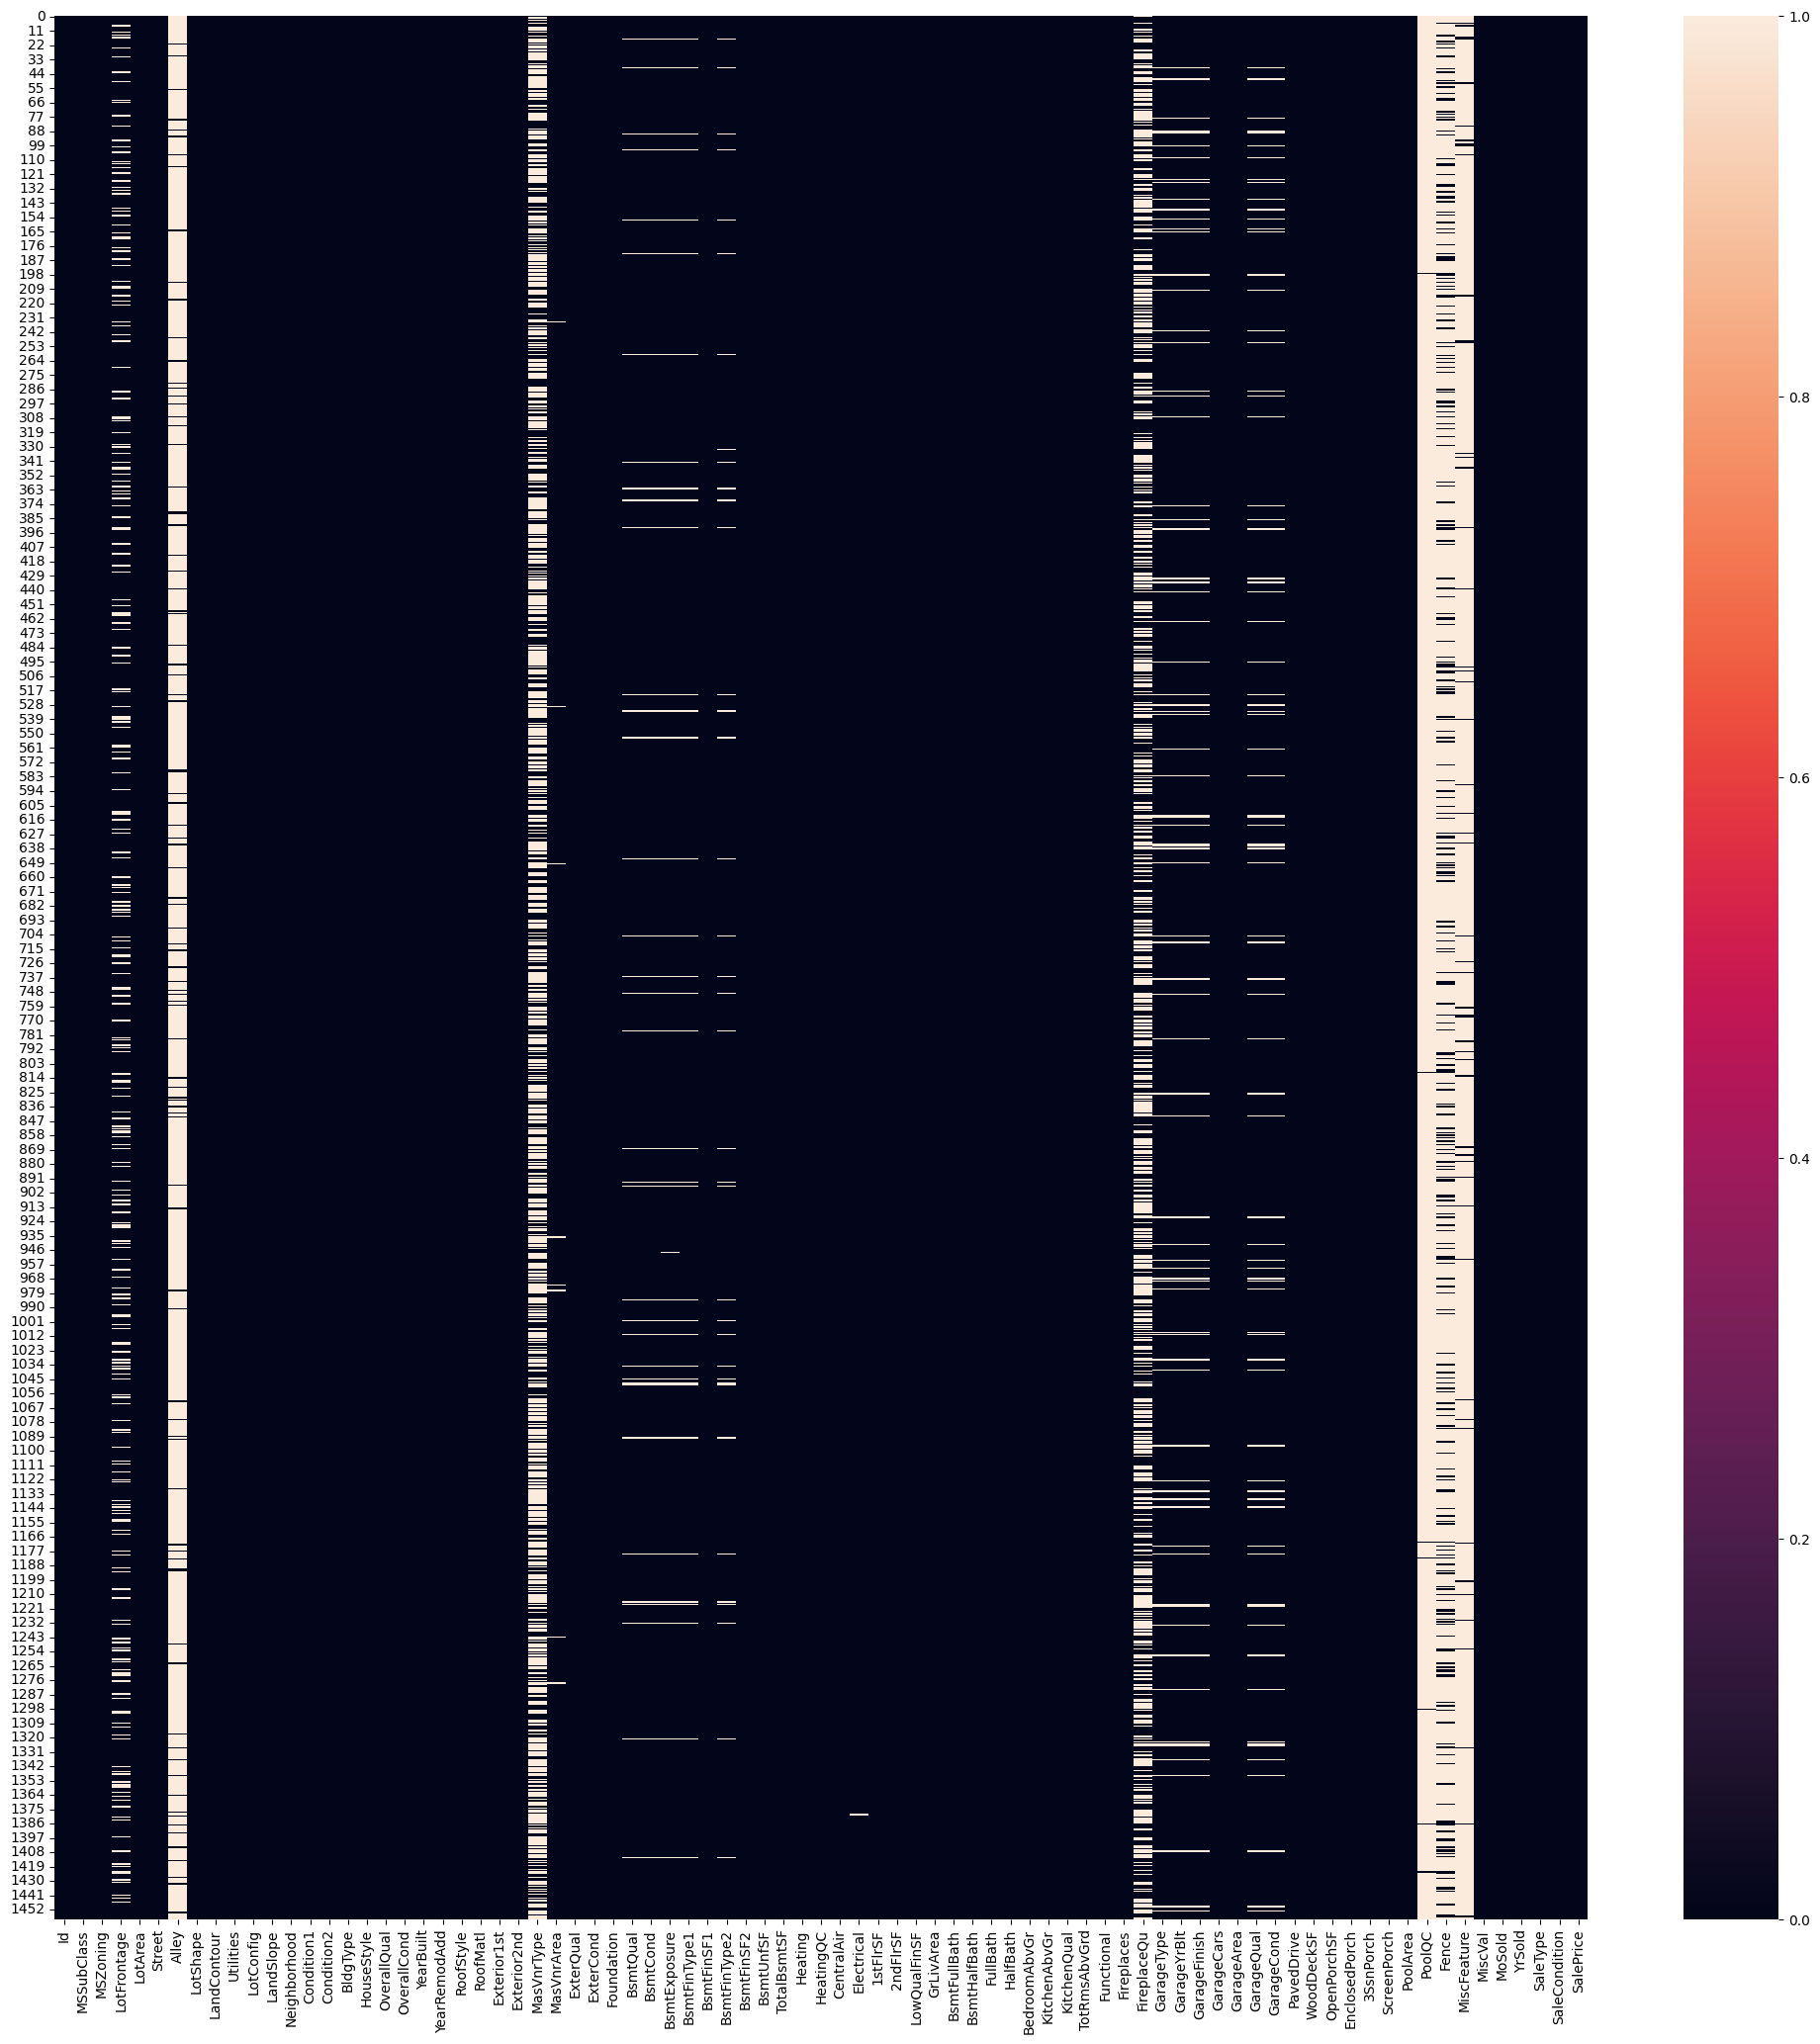

In [30]:
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.figure(figsize = (25,25))
sns.heatmap(df2.isnull())

In [31]:
df2.isnull().sum()/df.shape[0]*100

Id                  0.000000
MSSubClass          0.000000
MSZoning            0.000000
LotFrontage      8633.333333
LotArea             0.000000
                    ...     
MoSold              0.000000
YrSold              0.000000
SaleType            0.000000
SaleCondition       0.000000
SalePrice           0.000000
Length: 81, dtype: float64

In [32]:
null_var = df2.isnull().sum()/df2.shape[0]*100
null_var

Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

In [33]:
drop_columns = null_var[null_var > 17].keys()
drop_columns

Index(['LotFrontage', 'Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')

In [34]:
df2_drop_clm = df2.drop(columns = drop_columns)

In [35]:
df2.shape

(1460, 81)

In [36]:
df_drop_clm = df2.drop(columns=drop_columns)
df_drop_clm 

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,1457,20,RL,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,1458,70,RL,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,112,0,0,0,0,4,2010,WD,Normal,142125


In [37]:
df2.shape

(1460, 81)

<Axes: >

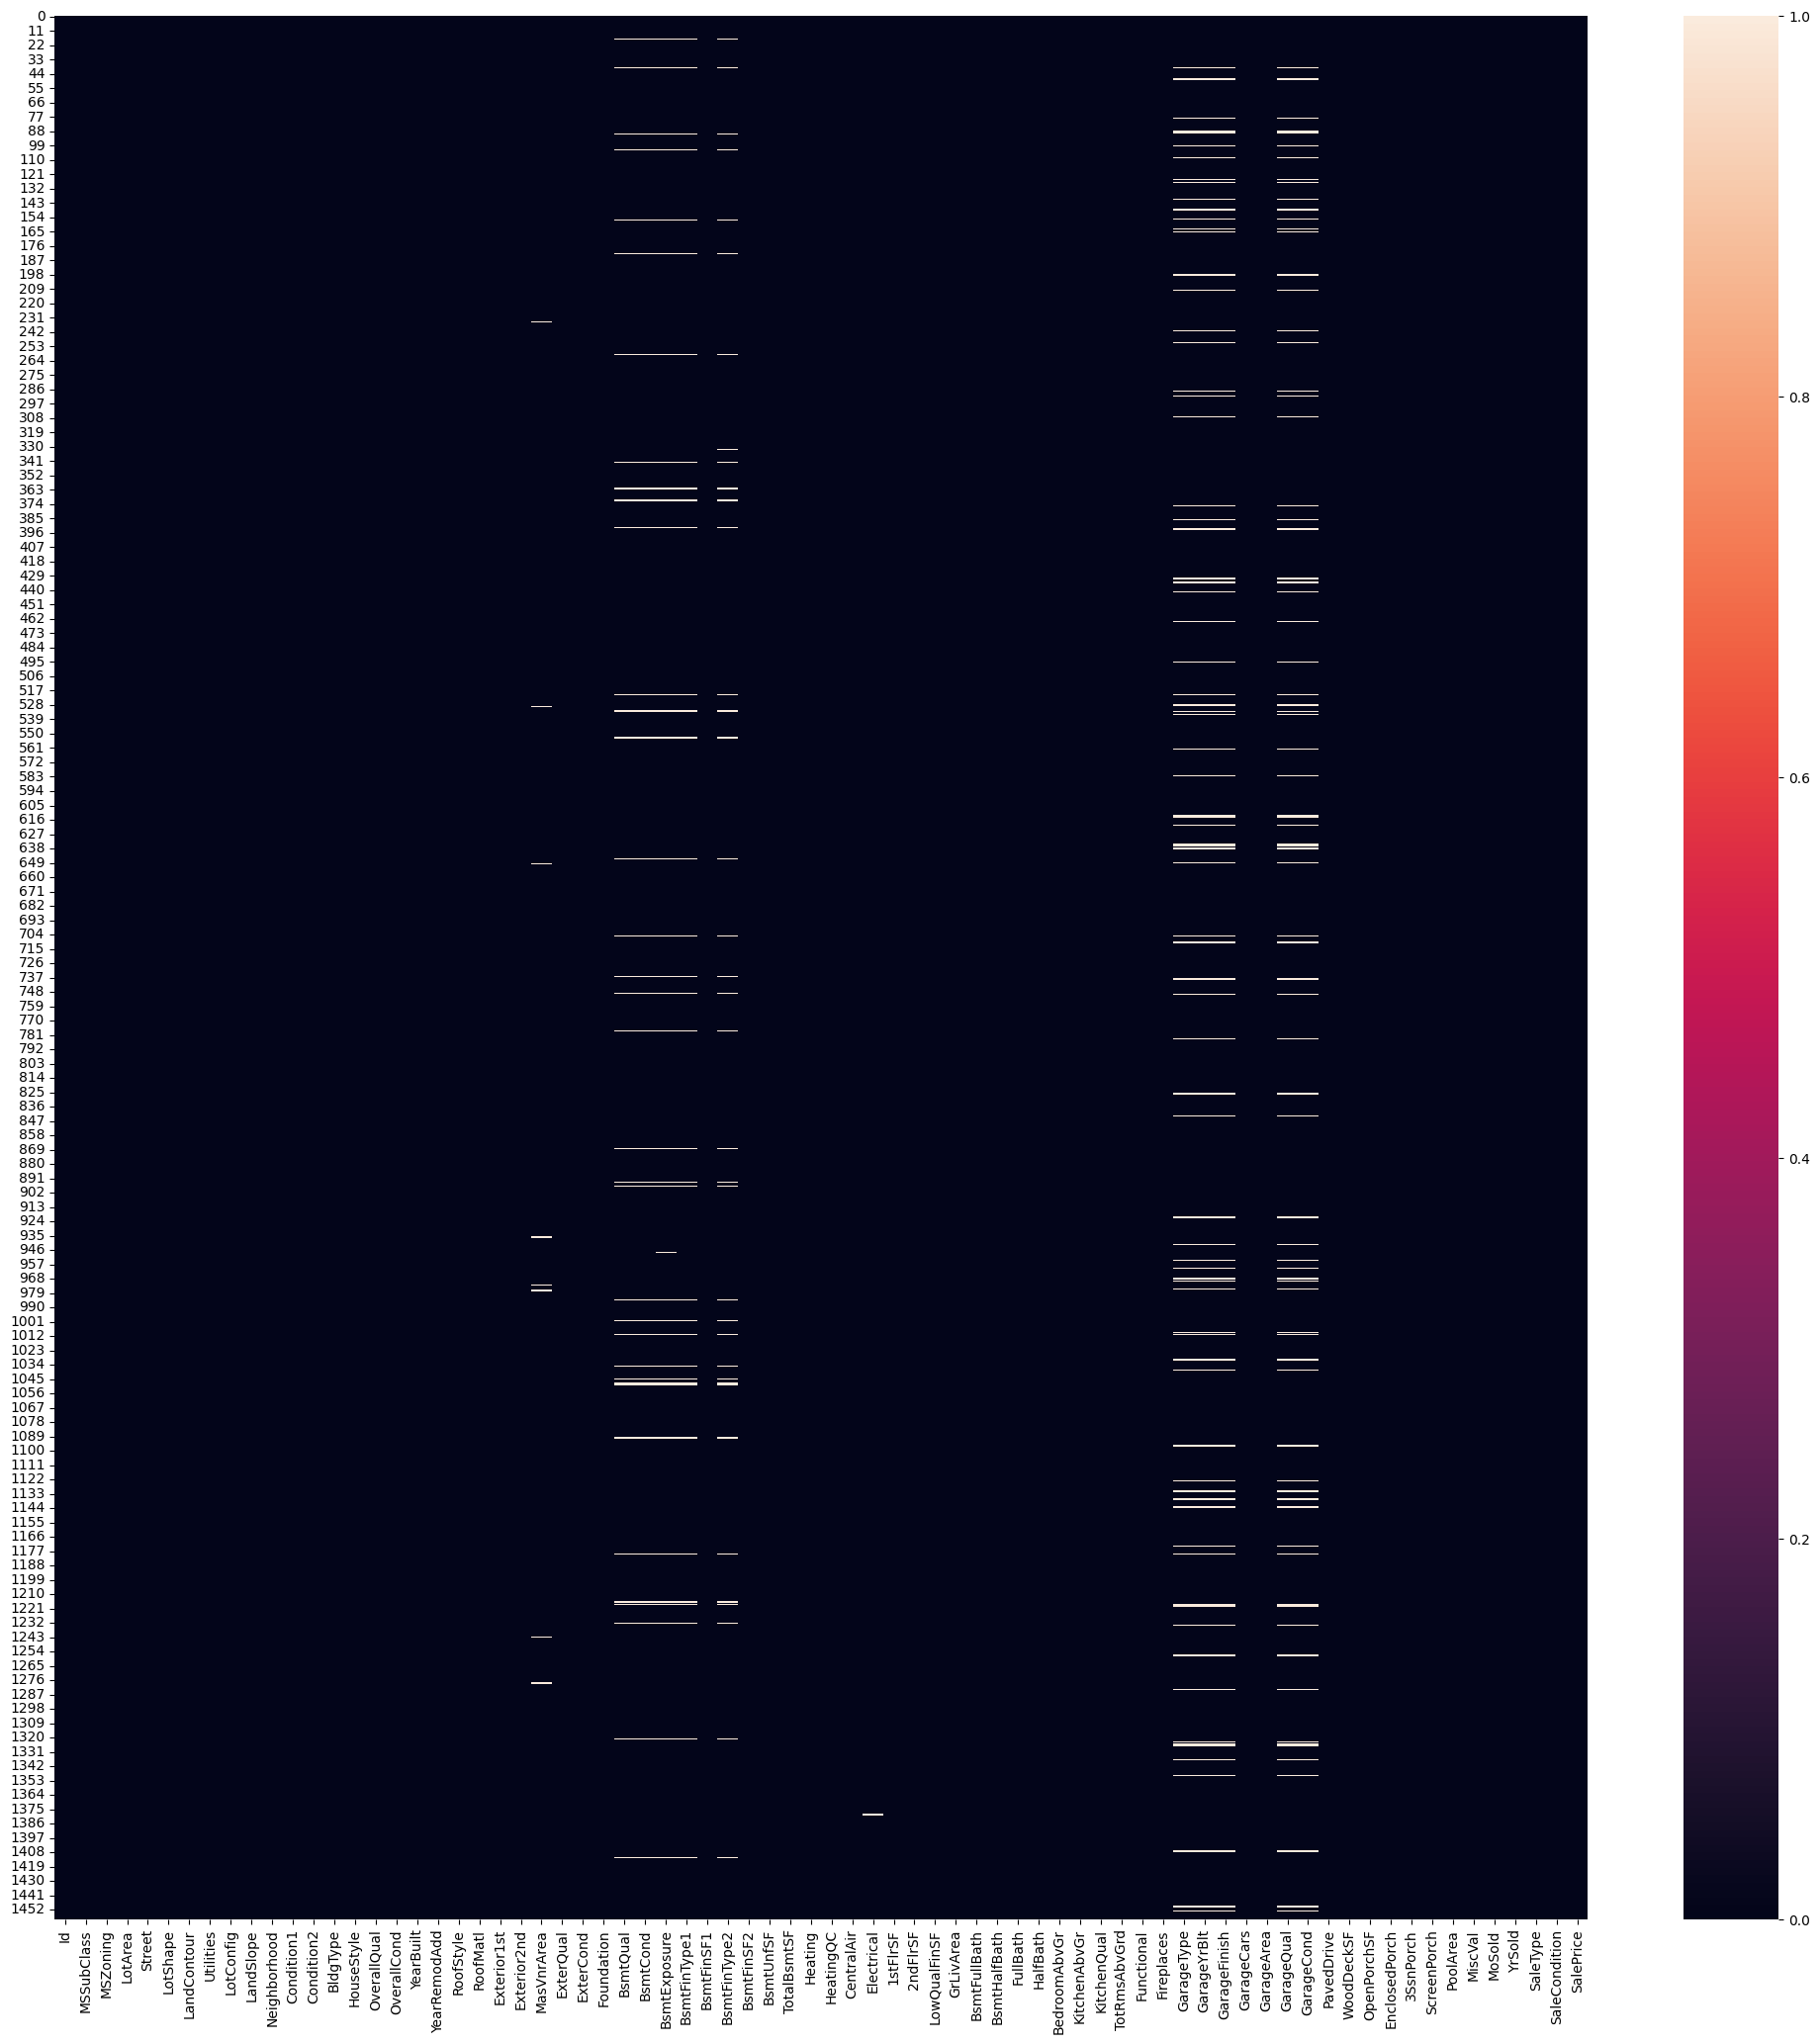

In [38]:
plt.figure(figsize = (25,25))
sns.heatmap(df2_drop_clm.isnull())

In [47]:
df2_drop_rows = df2_drop_clm.dropna()

In [48]:
df2_drop_rows.shape

(1338, 74)

<Axes: >

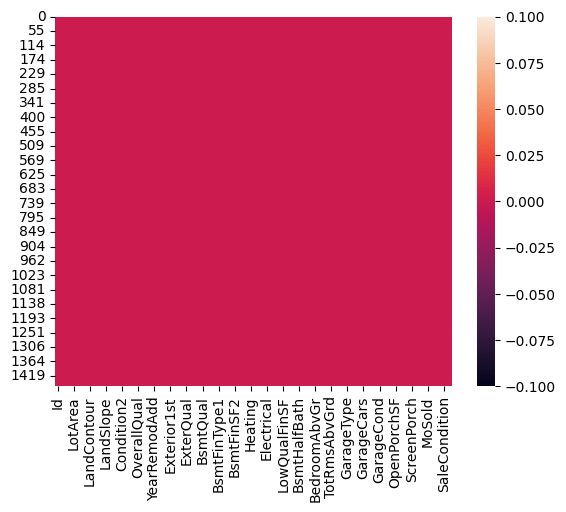

In [65]:
import seaborn as sns 
sns.heatmap(df2_drop_rows.isnull())

In [50]:
import seaborn as sns 

df2_drop_rows.select_dtypes(include = ['int64','float64']).columns

Index(['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

<Axes: xlabel='MSSubClass', ylabel='Count'>

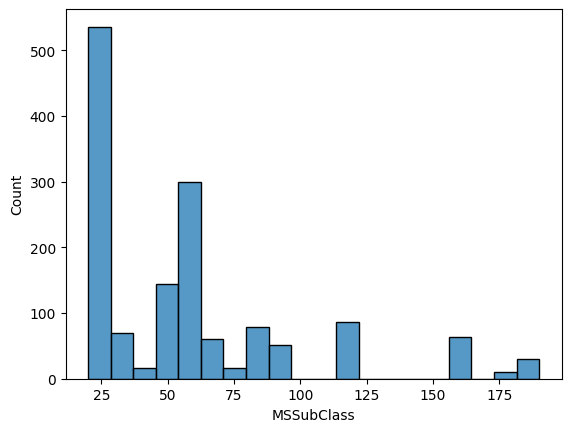

In [66]:
sns.histplot(df2['MSSubClass'])

In [57]:
num = ['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice']

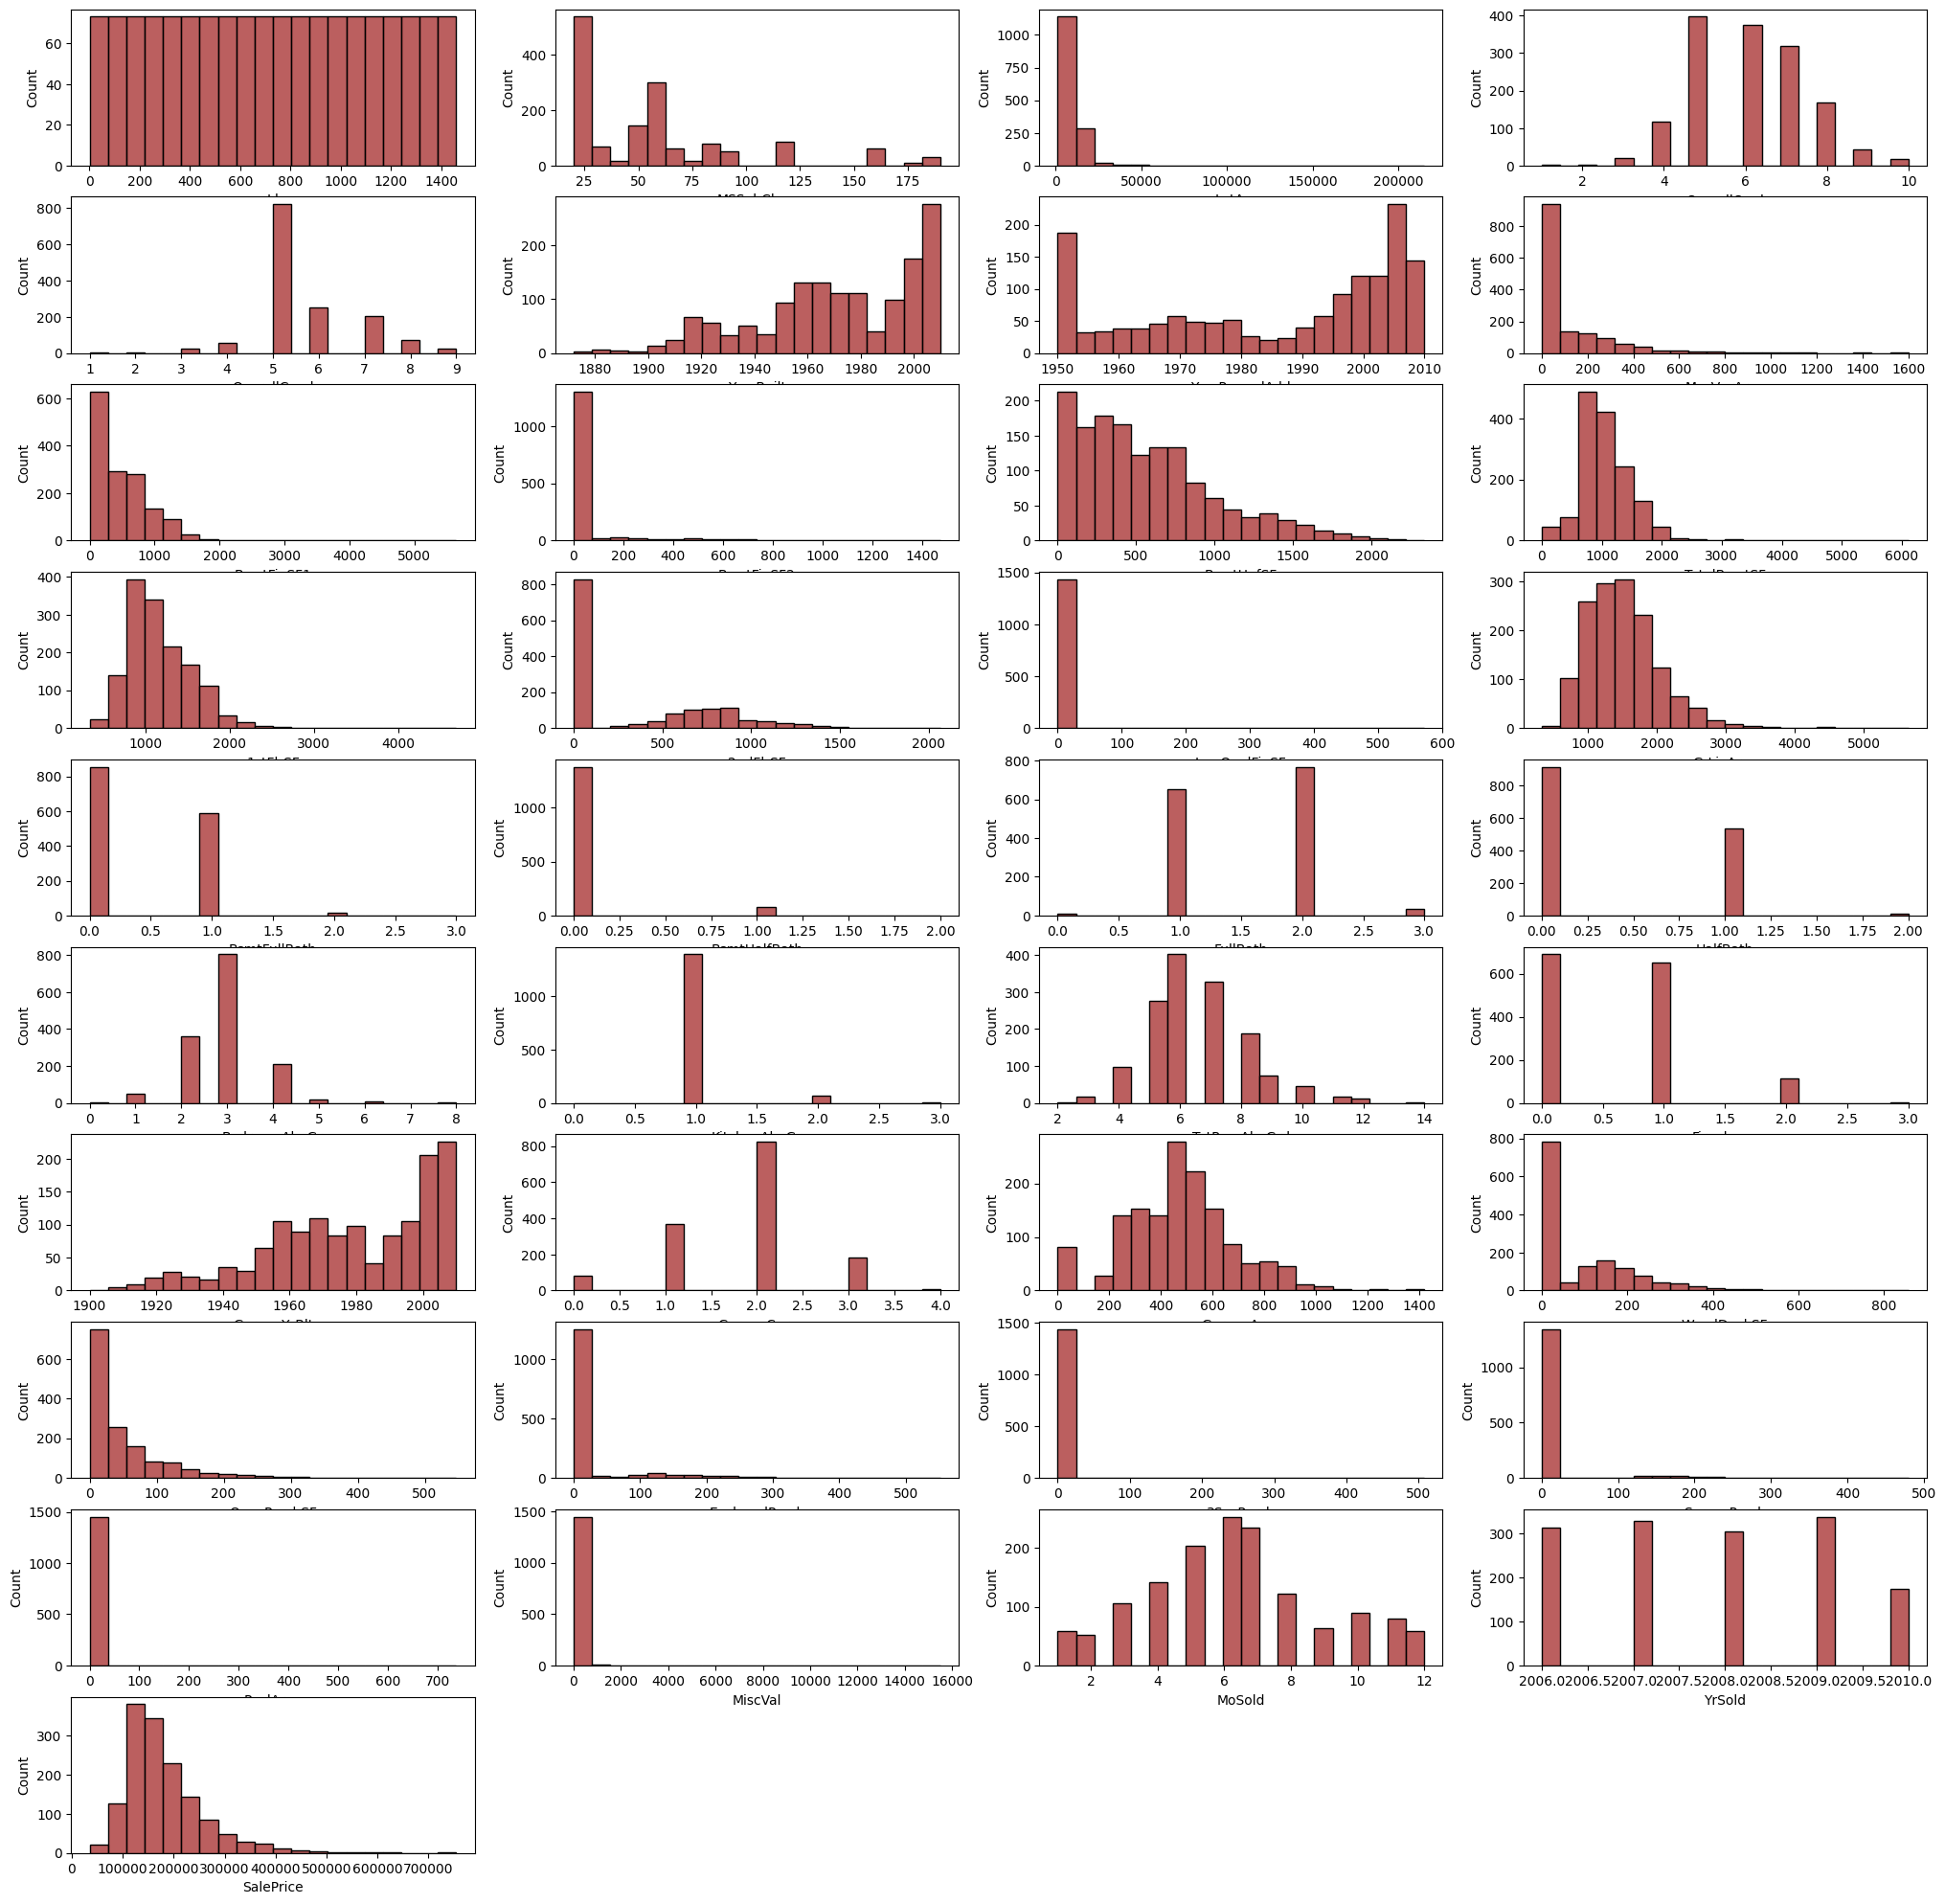

In [74]:
import math

cols = 4
rows = math.ceil(len(num)/cols)

plt.figure(figsize=(25,25))

for i, var in enumerate(num):
    plt.subplot(rows, cols, i+1)
    sns.histplot(df2[var], bins=20,color='brown')

In [68]:
df2_drop_rows.select_dtypes(include=['object']).columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [70]:
df2['MSZoning'].value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

In [71]:
df2['MSZoning'].value_counts()/df2_drop_rows.shape[0]

MSZoning
RL         0.860239
RM         0.162930
FV         0.048580
RH         0.011958
C (all)    0.007474
Name: count, dtype: float64

In [72]:
df2['MSZoning'].value_counts()/df2_drop_rows.shape[0]*100

MSZoning
RL         86.023916
RM         16.292975
FV          4.857997
RH          1.195815
C (all)     0.747384
Name: count, dtype: float64

In [94]:

pd.concat([df2['MSZoning'].value_counts()/df2.shape[1] * 100,
           df2_drop_rows['MSZoning'].value_counts()/df2_drop_rows.shape[0] * 100],
          axis = 1,
          keys = ['MSZoning_Org', 'MSZoning_Clean'])

,MSZoning_Org,MSZoning_Clean
MSZoning,,
RL,1420.987654,79.671151
RM,269.135802,14.275037
FV,80.246914,4.633782
RH,19.753086,0.822123
C (all),12.345679,0.597907


In [98]:
def categarical_var_dist(var):
     return pd.concat([df['MSZoning'].value_counts()/df.shape[0]*100,
            df2_drop_rows['MSZoning'].value_counts()/df2_drop_rows.shape[0]*100],
            axis = 1,
            keys = [var+'_org',var+'_clean'])

In [99]:
categarical_var_dist('Street')

KeyError: 'MSZoning'

In [79]:
cat_cols = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
            'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
            'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
            'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
            'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
            'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
            'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
            'SaleType', 'SaleCondition']

for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"{'='*50}")
    
    distribution = pd.concat(
        [
            df2[col].value_counts(normalize=True) * 100,
            df2_drop_rows[col].value_counts(normalize=True) * 100
        ],
        axis=1,
        keys=[f'{col}_Org', f'{col}_Clean']
    )


Column: MSZoning

Column: Street

Column: LotShape

Column: LandContour

Column: Utilities

Column: LotConfig

Column: LandSlope

Column: Neighborhood

Column: Condition1

Column: Condition2

Column: BldgType

Column: HouseStyle

Column: RoofStyle

Column: RoofMatl

Column: Exterior1st

Column: Exterior2nd

Column: ExterQual

Column: ExterCond

Column: Foundation

Column: BsmtQual

Column: BsmtCond

Column: BsmtExposure

Column: BsmtFinType1

Column: BsmtFinType2

Column: Heating

Column: HeatingQC

Column: CentralAir

Column: Electrical

Column: KitchenQual

Column: Functional

Column: GarageType

Column: GarageFinish

Column: GarageQual

Column: GarageCond

Column: PavedDrive

Column: SaleType

Column: SaleCondition
